# Load supported SSP templates

This notebook shows how to load and use the supported SSP templates. Currently we have support for custom build SSP templates stored in hdf5 format for which we provide a template based on Bruzual&Charlot2003 models. Additionally we support all SSP templates that the pyPipe3D project uses. Those templates come in astronomy friendly fits file format.

In [11]:
# NBVAL_SKIP
from rubix.spectra.ssp.templates import EMILES, EMILES_BASTI_BASE_CH_FITS_safe

EMILES_BASTI_BASE_CH_FITS_safe

HDF5SSPGrid(age=Array([ 0.03,  0.04,  0.05,  0.06,  0.07,  0.08,  0.09,  0.1 ,  0.15,
        0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,  0.45,  0.5 ,  0.6 ,  0.7 ,
        0.8 ,  0.9 ,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,  2.25,  2.5 ,
        2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.5 ,  5.  ,  5.5 ,
        6.  ,  6.5 ,  7.  ,  7.5 ,  8.  ,  8.5 ,  9.  ,  9.5 , 10.  ,
       10.5 , 11.  , 11.5 , 12.  , 12.5 , 13.  , 13.5 , 14.  ],      dtype=float32), metallicity=Array([0.0004595 , 0.00078035, 0.001557  , 0.00310662, 0.00634291,
       0.00798525, 0.01630378, 0.02005803, 0.02583975], dtype=float32), wavelength=Array([ 1680.2,  1681.1,  1682. , ..., 49997.6, 49998.5, 49999.4],      dtype=float32), flux=Array([[[2.48731747e-02, 2.46272404e-02, 2.46415921e-02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.73798203e-02, 1.72044802e-02, 1.71960723e-02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.39401369e-02, 1.38202570e-02, 1.38187977e-0

In [14]:
#NBVAL_SKIP
import numpy as np
np.log10(EMILES_BASTI_BASE_CH_FITS_safe.metallicity/0.0142)

array([-1.49      , -1.26      , -0.96      , -0.65999997, -0.35      ,
       -0.25000003,  0.06000002,  0.15      ,  0.26      ], dtype=float32)

In [2]:
# NBVAL_SKIP
print(EMILES.age)

[ 0.03        0.04        0.05        0.06        0.07        0.08
  0.09        0.09999999  0.14999999  0.19999999  0.25        0.29999998
  0.35        0.39999998  0.45        0.5         0.59999996  0.7
  0.79999995  0.9         1.          1.25        1.5         1.75
  2.          2.2499998   2.5         2.75        3.          3.2499998
  3.5         3.75        4.          4.4999995   5.          5.5
  6.          6.4999995   7.          7.5         8.          8.499999
  8.999999    9.5        10.         10.499999   11.         11.5
 12.         12.499999   12.999999   13.5        14.        ]


# Load SSP template via custom config

This shows how to use a custom configuration to load an SSP template that is stored under some file location on your disk.

In [3]:
# NBVAL_SKIP
config_emiles = {
        "name": "EMILES",
        "format": "HDF5",
        "source": "https://github.com/kateharborne/SimSpin/tree/main/data/",
        "file_name": "EMILES.h5",
        "fields": {
            "age": {
                "name": "age",
                "units": "yr",
                "in_log": False
            },
            "metallicity": {
                "name": "metallicity",
                "units": "",
                "in_log": False
            },
            "wavelength": {
                "name": "wavelength",
                "units": "Angstrom",
                "in_log": False
            },
            "flux": {
                "name": "flux",
                "units": "Lsun/Angstrom",
                "in_log": False
            }
        }
    }

In [4]:
# NBVAL_SKIP
from rubix.spectra.ssp.grid import HDF5SSPGrid
ssp_emiles = HDF5SSPGrid.from_file(config_emiles, file_location="../rubix/spectra/ssp/templates")
ssp_emiles

HDF5SSPGrid(age=Array([ 0.03      ,  0.04      ,  0.05      ,  0.06      ,  0.07      ,
        0.08      ,  0.09      ,  0.09999999,  0.14999999,  0.19999999,
        0.25      ,  0.29999998,  0.35      ,  0.39999998,  0.45      ,
        0.5       ,  0.59999996,  0.7       ,  0.79999995,  0.9       ,
        1.        ,  1.25      ,  1.5       ,  1.75      ,  2.        ,
        2.2499998 ,  2.5       ,  2.75      ,  3.        ,  3.2499998 ,
        3.5       ,  3.75      ,  4.        ,  4.4999995 ,  5.        ,
        5.5       ,  6.        ,  6.4999995 ,  7.        ,  7.5       ,
        8.        ,  8.499999  ,  8.999999  ,  9.5       , 10.        ,
       10.499999  , 11.        , 11.5       , 12.        , 12.499999  ,
       12.999999  , 13.5       , 14.        ], dtype=float32), metallicity=Array([0.0001, 0.0003, 0.0006, 0.001 , 0.002 , 0.004 , 0.008 , 0.01  ,
       0.0198, 0.024 , 0.03  , 0.04  ], dtype=float32), wavelength=Array([ 1680.2,  1681.1,  1682. , ..., 19997.9, 199

In [5]:
# NBVAL_SKIP
ssp_emiles.age.shape

(53,)

In [6]:
# NBVAL_SKIP
ssp_emiles.metallicity.shape

(12,)

In [7]:
# NBVAL_SKIP
ssp_emiles.wavelength.shape

(20356,)

In [8]:
# NBVAL_SKIP
ssp_emiles.flux.shape

(20356, 53, 12)

# Let's plot some example spectra

In [9]:
# NBVAL_SKIP
import matplotlib.pyplot as plt
import numpy as np

ValueError: x and y must have same first dimension, but have shapes (20356,) and (12,)

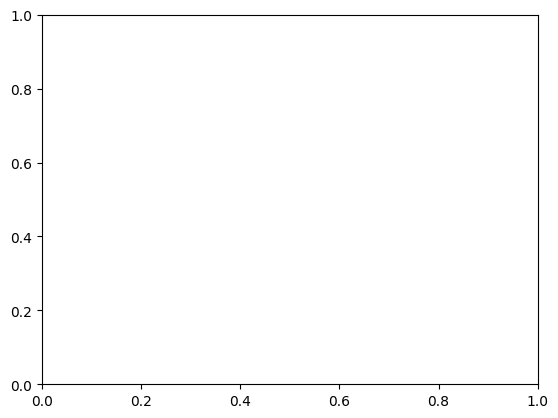

In [10]:
# NBVAL_SKIP
plt.plot(ssp_emiles.wavelength,ssp_emiles.flux[0][0])
plt.xlabel(r'$\lambda$ [%s]'%config_emiles["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config_emiles["fields"]["flux"]["units"])
#plt.yscale("log")

Text(0, 0.5, 'Flux [Lsun/Angstrom]')

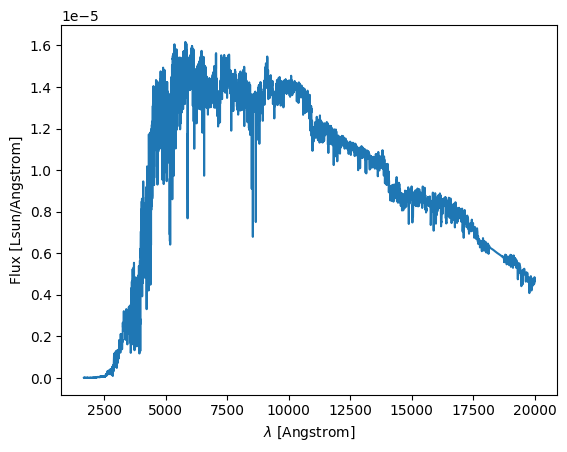

In [ ]:
# NBVAL_SKIP
plt.plot(ssp_emiles.wavelength,ssp_emiles.flux[-1][-1])
plt.xlabel(r'$\lambda$ [%s]'%config_emiles["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config_emiles["fields"]["flux"]["units"])
#plt.yscale("log")

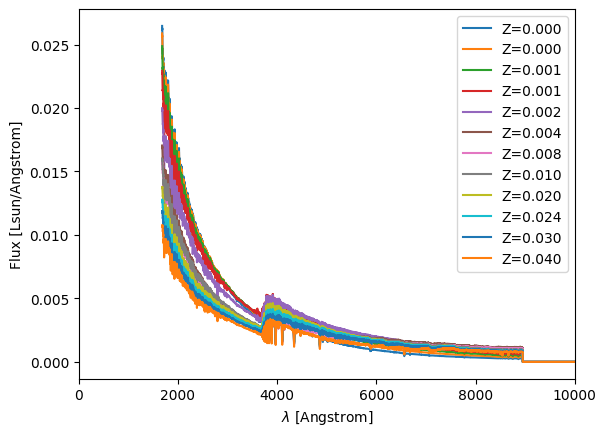

In [ ]:
# NBVAL_SKIP
for i in range(len(ssp_emiles.metallicity)):
    plt.plot(ssp_emiles.wavelength,ssp_emiles.flux[i][0], label=r'Z=%0.3f'%ssp_emiles.metallicity[i])
plt.xlabel(r'$\lambda$ [%s]'%config_emiles["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config_emiles["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,10000)
plt.legend()

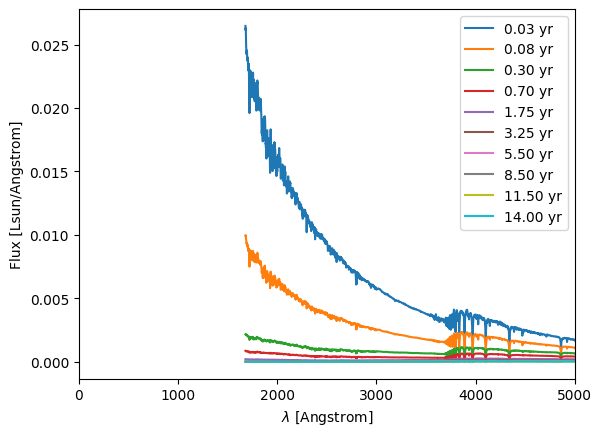

In [ ]:
# NBVAL_SKIP
ages = np.linspace(0,len(ssp_emiles.age),10)
for age in ages:
    plt.plot(ssp_emiles.wavelength,ssp_emiles.flux[0][int(age)], label='%.2f %s'%(ssp_emiles.age[int(age)], config_emiles["fields"]["age"]["units"]))
plt.xlabel(r'$\lambda$ [%s]'%config_emiles["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config_emiles["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,5000)
plt.legend()